# Action Recognition in Videos



## 1. Install Dependencies


In [ ]:
!nvidia-smi
!apt-get update
!apt-get install -y unrar
!pip install torch torchvision opencv-python scikit-learn matplotlib seaborn tqdm pandas pillow


Thu Aug 13 17:40:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Configuration & Imports


In [ ]:
import os
import random
import urllib.request
import subprocess
import glob
import shutil
import time
import ssl
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.models.video as video_models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Bypass SSL to ensure Dataset Download works
ssl._create_default_https_context = ssl._create_unverified_context

class Config:
    SEED = 42
    BASE_DIR = "/content"
    DATA_DIR = os.path.join(BASE_DIR, "data")
    TRAIN_DIR = os.path.join(DATA_DIR, "train")
    VAL_DIR = os.path.join(DATA_DIR, "val")
    TEST_DIR = os.path.join(DATA_DIR, "test")
    CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")
    OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
    BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pth")

    NUM_FRAMES = 16
    FRAME_HEIGHT = 112
    FRAME_WIDTH = 112
    FPS = 15

    MODEL_NAME = "r2plus1d_18"
    PRETRAINED = True
    BATCH_SIZE = 8
    # SET NUM_WORKERS to 0 to prevent Colab Shared Memory (Bus Error) crashes in DataLoader
    NUM_WORKERS = 0
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4
    NUM_EPOCHS = 10
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    CLASSES = [
        "Archery", "Basketball", "Biking", "Bowling", "BoxingPunching",
        "Diving", "Fencing", "GolfSwing", "HorseRiding", "SoccerJuggling"
    ]

def set_seed(seed=Config.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
os.makedirs(Config.DATA_DIR, exist_ok=True)



## 3. Download & Prepare UCF101 Dataset


In [ ]:
UCF101_URL = "https://www.crcv.ucf.edu/data/UCF101/UCF101.rar"

def download_and_extract_ucf101():
    rar_path = os.path.join(Config.DATA_DIR, "UCF101.rar")
    raw_extracted_dir = os.path.join(Config.DATA_DIR, "UCF-101")

    if not os.path.exists(rar_path) or os.path.getsize(rar_path) < 6500000000:
        print(f"Downloading UCF101 (6.5 GB) using wget...")
        subprocess.run(["wget", "-c", "--no-check-certificate", UCF101_URL, "-O", rar_path], check=True)
        print("Download complete.")

    if not os.path.exists(raw_extracted_dir):
        print("Extracting UCF101...")
        subprocess.run(["unrar", "x", "-y", rar_path, Config.DATA_DIR], check=True, stdout=subprocess.DEVNULL)
        print("Extraction complete.")

    print(f"Splitting 10 selected classes...")
    for cls_name in Config.CLASSES:
        cls_raw_path = os.path.join(raw_extracted_dir, cls_name)
        if not os.path.exists(cls_raw_path): continue

        video_files = glob.glob(os.path.join(cls_raw_path, "*.avi"))
        random.shuffle(video_files)
        total = len(video_files)

        train_count, val_count = int(total * 0.7), int(total * 0.15)
        splits = {
            "train": video_files[:train_count],
            "val": video_files[train_count:train_count + val_count],
            "test": video_files[train_count + val_count:]
        }

        for split_name, files in splits.items():
            dest_folder = os.path.join(Config.DATA_DIR, split_name, cls_name)
            os.makedirs(dest_folder, exist_ok=True)
            for fpath in files:
                dest_file = os.path.join(dest_folder, os.path.basename(fpath))
                if not os.path.exists(dest_file):
                    shutil.copy(fpath, dest_file)
        print(f"Prepared '{cls_name}' -> Train: {len(splits['train'])}, Val: {len(splits['val'])}, Test: {len(splits['test'])}")

download_and_extract_ucf101()


Download complete.
Extracting UCF101...
Extraction complete.
Splitting 10 selected classes...
Prepared 'Archery' -> Train: 101, Val: 21, Test: 23
Prepared 'Basketball' -> Train: 93, Val: 20, Test: 21
Prepared 'Biking' -> Train: 93, Val: 20, Test: 21
Prepared 'Bowling' -> Train: 108, Val: 23, Test: 24
Prepared 'Diving' -> Train: 105, Val: 22, Test: 23
Prepared 'Fencing' -> Train: 77, Val: 16, Test: 18
Prepared 'GolfSwing' -> Train: 97, Val: 20, Test: 22
Prepared 'HorseRiding' -> Train: 114, Val: 24, Test: 26
Prepared 'SoccerJuggling' -> Train: 102, Val: 22, Test: 23


## 4. Video Transforms & Dataset


In [ ]:
class ComposeVideoTransforms:
    def __init__(self, transforms): self.transforms = transforms
    def __call__(self, clip):
        for t in self.transforms: clip = t(clip)
        return clip

class VideoResize:
    def __init__(self, size): self.size = size
    def __call__(self, clip):
        if clip.dim() == 4 and clip.size(-1) in [1, 3]: clip = clip.permute(0, 3, 1, 2)
        # Frames are already resized in _read_frames, but this acts as a safety fallback
        return torch.stack([TF.resize(frame, self.size, antialias=True) for frame in clip])

class VideoRandomHorizontalFlip:
    def __init__(self, p=0.5): self.p = p
    def __call__(self, clip):
        if random.random() < self.p: return torch.stack([TF.hflip(frame) for frame in clip])
        return clip

class VideoNormalize:
    def __init__(self, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
        self.mean, self.std = mean, std
    def __call__(self, clip):
        if clip.dtype == torch.uint8: clip = clip.float() / 255.0
        normalized = [TF.normalize(frame, mean=self.mean, std=self.std) for frame in clip]
        return torch.stack(normalized).permute(1, 0, 2, 3)

def get_transforms(is_train=True):
    if is_train:
        return ComposeVideoTransforms([VideoResize((Config.FRAME_HEIGHT, Config.FRAME_WIDTH)), VideoRandomHorizontalFlip(), VideoNormalize()])
    return ComposeVideoTransforms([VideoResize((Config.FRAME_HEIGHT, Config.FRAME_WIDTH)), VideoNormalize()])

class VideoActionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.video_paths = []
        self.labels = []
        self.classes = Config.CLASSES
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for cls_name in self.classes:
            cls_folder = os.path.join(root_dir, cls_name)
            if not os.path.exists(cls_folder): continue
            for ext in ("*.mp4", "*.avi"):
                for video_path in glob.glob(os.path.join(cls_folder, ext)):
                    self.video_paths.append(video_path)
                    self.labels.append(self.class_to_idx[cls_name])

    def __len__(self): return len(self.video_paths)

    def _read_frames(self, path):
        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0: return torch.zeros((Config.NUM_FRAMES, Config.FRAME_HEIGHT, Config.FRAME_WIDTH, 3), dtype=torch.uint8)

        indices = np.linspace(0, max(0, total - 1), Config.NUM_FRAMES, dtype=int)
        frames = []
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        idx = 0
        while cap.isOpened() and len(frames) < len(indices):
            ret, frame = cap.read()
            if not ret: break
            if idx in indices:
                # BULLETPROOF FIX: Resize immediately to guarantee homogeneous shapes!
                frame = cv2.resize(frame, (Config.FRAME_WIDTH, Config.FRAME_HEIGHT))
                frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            idx += 1
        cap.release()

        pad_shape = (Config.FRAME_HEIGHT, Config.FRAME_WIDTH, 3)
        while len(frames) < Config.NUM_FRAMES:
            frames.append(np.zeros(pad_shape, dtype=np.uint8))

        return torch.from_numpy(np.array(frames[:Config.NUM_FRAMES], dtype=np.uint8))

    def __getitem__(self, idx):
        frames = self._read_frames(self.video_paths[idx])
        if self.transform: return self.transform(frames), self.labels[idx]
        return frames.permute(3, 0, 1, 2).float() / 255.0, self.labels[idx]



## 5. Model Definition (3D CNN)


In [ ]:
def get_model():
    print(f"Initializing {Config.MODEL_NAME} (Pretrained={Config.PRETRAINED})...")
    weights = video_models.R2Plus1D_18_Weights.DEFAULT if Config.PRETRAINED else None
    model = video_models.r2plus1d_18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, len(Config.CLASSES))
    return model



## 6. Training Pipeline


In [ ]:
def calculate_topk_accuracy(output, target, topk=(1, 5)):
    with torch.no_grad():
        maxk = min(max(topk), output.size(1))
        actual_topk = tuple(min(k, output.size(1)) for k in topk)
        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        res = []
        for k in actual_topk:
            res.append(correct[:k].reshape(-1).float().sum(0, keepdim=True).mul_(100.0 / target.size(0)).item())
        while len(res) < len(topk): res.append(res[0])
        return res

train_dataset = VideoActionDataset(Config.TRAIN_DIR, transform=get_transforms(True))
val_dataset = VideoActionDataset(Config.VAL_DIR, transform=get_transforms(False))
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)

model = get_model().to(Config.DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)

best_val = 0.0
for epoch in range(1, Config.NUM_EPOCHS + 1):
    model.train()
    train_loss, train_t1 = 0, 0
    for clips, labels in train_loader:
        clips, labels = clips.to(Config.DEVICE), labels.to(Config.DEVICE)
        optimizer.zero_grad()
        out = model(clips)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * labels.size(0)
        train_t1 += calculate_topk_accuracy(out, labels, (1,))[0] * labels.size(0)

    model.eval()
    val_loss, val_t1, val_t5 = 0, 0, 0
    with torch.no_grad():
        for clips, labels in val_loader:
            clips, labels = clips.to(Config.DEVICE), labels.to(Config.DEVICE)
            out = model(clips)
            val_loss += criterion(out, labels).item() * labels.size(0)
            t1, t5 = calculate_topk_accuracy(out, labels, (1, 5))
            val_t1 += t1 * labels.size(0)
            val_t5 += t5 * labels.size(0)

    train_loss /= len(train_dataset)
    train_t1 /= len(train_dataset)
    val_loss /= len(val_dataset)
    val_t1 /= len(val_dataset)
    val_t5 /= len(val_dataset)

    print(f"Epoch {epoch}/{Config.NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_t1:.1f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_t1:.1f}% | Val Top-5: {val_t5:.1f}%")
    if val_t1 >= best_val:
        best_val = val_t1
        torch.save(model.state_dict(), Config.BEST_MODEL_PATH)
        print("  -> Saved best model!")



Initializing r2plus1d_18 (Pretrained=True)...
Downloading: "https://download.pytorch.org/models/r2plus1d_18-91a641e6.pth" to /root/.cache/torch/hub/checkpoints/r2plus1d_18-91a641e6.pth


100%|██████████| 120M/120M [00:00<00:00, 189MB/s]


Epoch 1/10 | Train Loss: 0.5191 | Train Acc: 88.3% | Val Loss: 0.0898 | Val Acc: 98.4% | Val Top-5: 100.0%
  -> Saved best model!
Epoch 2/10 | Train Loss: 0.1255 | Train Acc: 97.6% | Val Loss: 0.0221 | Val Acc: 99.5% | Val Top-5: 100.0%
  -> Saved best model!
Epoch 3/10 | Train Loss: 0.0968 | Train Acc: 98.3% | Val Loss: 0.0263 | Val Acc: 99.5% | Val Top-5: 100.0%
  -> Saved best model!
Epoch 4/10 | Train Loss: 0.0673 | Train Acc: 98.1% | Val Loss: 0.0107 | Val Acc: 100.0% | Val Top-5: 100.0%
  -> Saved best model!
Epoch 5/10 | Train Loss: 0.0838 | Train Acc: 98.2% | Val Loss: 0.0334 | Val Acc: 98.9% | Val Top-5: 100.0%
Epoch 6/10 | Train Loss: 0.0698 | Train Acc: 98.3% | Val Loss: 0.0095 | Val Acc: 100.0% | Val Top-5: 100.0%
  -> Saved best model!
Epoch 7/10 | Train Loss: 0.0328 | Train Acc: 99.6% | Val Loss: 0.0215 | Val Acc: 99.5% | Val Top-5: 100.0%
Epoch 8/10 | Train Loss: 0.0264 | Train Acc: 99.6% | Val Loss: 0.0044 | Val Acc: 100.0% | Val Top-5: 100.0%
  -> Saved best model!
Epo

## 7. Evaluation & Metrics


Test Top-1 Accuracy: 98.51%
Test Top-5 Accuracy: 100.00%
Average Inference Latency: 5.92 ms

Classification Report:
                precision    recall  f1-score   support

       Archery       0.96      1.00      0.98        23
    Basketball       1.00      0.95      0.98        21
        Biking       1.00      0.95      0.98        21
       Bowling       1.00      0.96      0.98        24
BoxingPunching       0.00      0.00      0.00         0
        Diving       1.00      1.00      1.00        23
       Fencing       0.95      1.00      0.97        18
     GolfSwing       1.00      1.00      1.00        22
   HorseRiding       0.96      1.00      0.98        26
SoccerJuggling       1.00      1.00      1.00        23

      accuracy                           0.99       201
     macro avg       0.89      0.89      0.89       201
  weighted avg       0.99      0.99      0.99       201



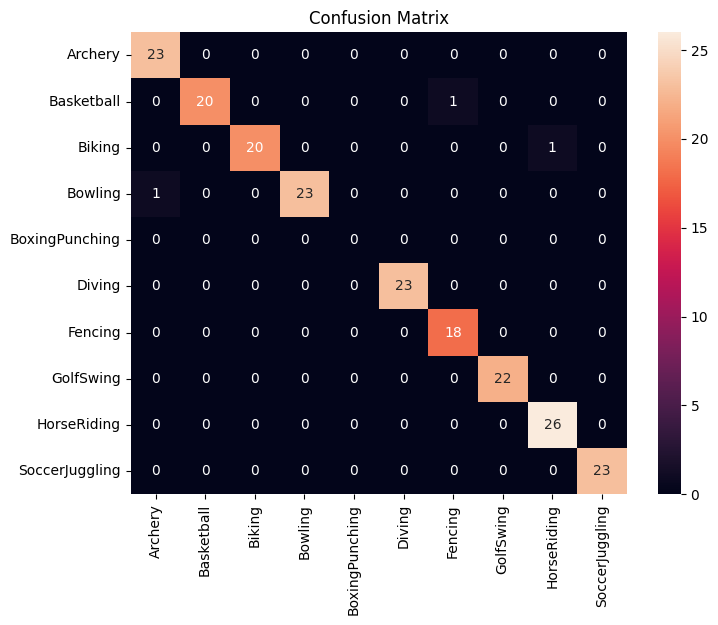

In [ ]:
test_dataset = VideoActionDataset(Config.TEST_DIR, transform=get_transforms(False))
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=Config.NUM_WORKERS)

model.load_state_dict(torch.load(Config.BEST_MODEL_PATH))
model.eval()

all_preds, all_targets, times = [], [], []
top1_sum, top5_sum = 0, 0

with torch.no_grad():
    for clips, labels in test_loader:
        clips, labels = clips.to(Config.DEVICE), labels.to(Config.DEVICE)
        st = time.time()
        out = model(clips)
        times.append((time.time() - st) * 1000)

        t1, t5 = calculate_topk_accuracy(out, labels, (1, 5))
        top1_sum += t1
        top5_sum += t5
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

print(f"Test Top-1 Accuracy: {top1_sum / len(test_dataset):.2f}%")
print(f"Test Top-5 Accuracy: {top5_sum / len(test_dataset):.2f}%")
print(f"Average Inference Latency: {sum(times)/len(times):.2f} ms")

print("\nClassification Report:")
print(classification_report(all_targets, all_preds, labels=range(len(Config.CLASSES)), target_names=Config.CLASSES, zero_division=0))

cm = confusion_matrix(all_targets, all_preds, labels=range(len(Config.CLASSES)))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=Config.CLASSES, yticklabels=Config.CLASSES)
plt.title("Confusion Matrix")
plt.savefig(os.path.join(Config.OUTPUT_DIR, "confusion_matrix.png"))
plt.show()


## 8. Visualization on Sample Video Clips


In [12]:
archery_videos = glob.glob("data/test/Archery/*.avi")

if archery_videos:
    visualize_prediction(archery_videos[0])
else:
    print("Archery folder is empty!")


Running inference on /content/data/test/Archery/v_Archery_g02_c03.avi...
Prediction: Archery (100.0%)
Saved annotated video to /content/outputs/annotated_v_Archery_g02_c03.avi
